In [1]:
import pandas as pd

df = pd.read_csv(
    "US_Accidents_March23.csv",
    nrows=100000
)

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [2]:
print(df.shape)

df.info()

(100000, 46)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  str    
 11  Street                 100000 non-null  str    
 12  City                   99999 non-null   str    
 13  County                 100000 non-null  str    
 14  State                  100000 non-n

In [3]:
df.isnull().sum().sort_values(ascending=False)

End_Lng                  100000
End_Lat                  100000
Wind_Chill(F)             95678
Precipitation(in)         92632
Wind_Speed(mph)           23820
Humidity(%)                1856
Visibility(mi)             1846
Weather_Condition          1604
Temperature(F)             1591
Pressure(in)               1292
Wind_Direction             1064
Weather_Timestamp          1054
Timezone                      7
Zipcode                       7
Airport_Code                  7
Nautical_Twilight             1
Civil_Twilight                1
City                          1
Astronomical_Twilight         1
Sunrise_Sunset                1
Description                   0
Street                        0
Source                        0
ID                            0
Severity                      0
Distance(mi)                  0
Start_Lng                     0
Start_Time                    0
End_Time                      0
Start_Lat                     0
County                        0
Amenity 

In [6]:
df.drop(
    columns=[
        'End_Lat',
        'End_Lng',
        'Wind_Chill(F)',
        'Precipitation(in)'
    ],
    inplace=True,
    errors='ignore'
)

df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())

df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df['Weather_Condition'].mode()[0]
)

print(df.isnull().sum().sort_values(ascending=False).head(10))

Wind_Direction           1064
Weather_Timestamp        1054
Zipcode                     7
Timezone                    7
Airport_Code                7
City                        1
Sunrise_Sunset              1
Civil_Twilight              1
Nautical_Twilight           1
Astronomical_Twilight       1
dtype: int64


In [7]:
# Fill remaining categorical missing values

df['Wind_Direction'] = df['Wind_Direction'].fillna(df['Wind_Direction'].mode()[0])

df['Weather_Timestamp'] = df['Weather_Timestamp'].fillna(df['Weather_Timestamp'].mode()[0])

df['Zipcode'] = df['Zipcode'].fillna(df['Zipcode'].mode()[0])

df['Timezone'] = df['Timezone'].fillna(df['Timezone'].mode()[0])

df['Airport_Code'] = df['Airport_Code'].fillna(df['Airport_Code'].mode()[0])

df['City'] = df['City'].fillna(df['City'].mode()[0])

df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].mode()[0])

df['Civil_Twilight'] = df['Civil_Twilight'].fillna(df['Civil_Twilight'].mode()[0])

df['Nautical_Twilight'] = df['Nautical_Twilight'].fillna(df['Nautical_Twilight'].mode()[0])

df['Astronomical_Twilight'] = df['Astronomical_Twilight'].fillna(df['Astronomical_Twilight'].mode()[0])

print(df.isnull().sum().sort_values(ascending=False).head(10))

ID              0
Source          0
Severity        0
Start_Time      0
End_Time        0
Start_Lat       0
Start_Lng       0
Distance(mi)    0
Description     0
Street          0
dtype: int64


In [8]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour

df[['Start_Time', 'Hour']].head()

,Start_Time,Hour
0,2016-02-08 05:46:00,5
1,2016-02-08 06:07:59,6
2,2016-02-08 06:49:27,6
3,2016-02-08 07:23:34,7
4,2016-02-08 07:39:07,7


C:\Users\anura\AppData\Local\Temp\ipykernel_17784\863083104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


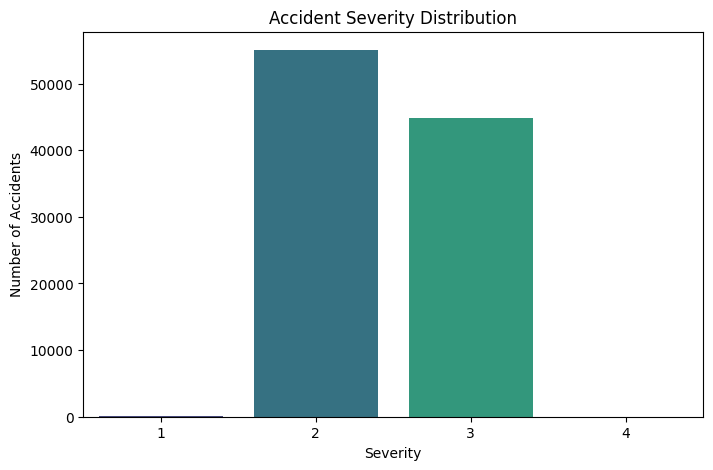

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Severity',
    palette='viridis'
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

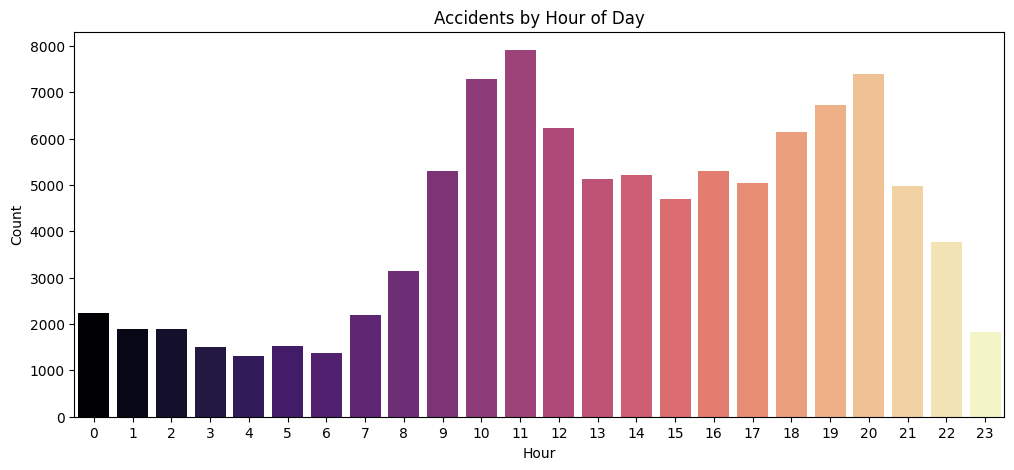

In [11]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='Hour',
    hue='Hour',
    palette='magma',
    legend=False
)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

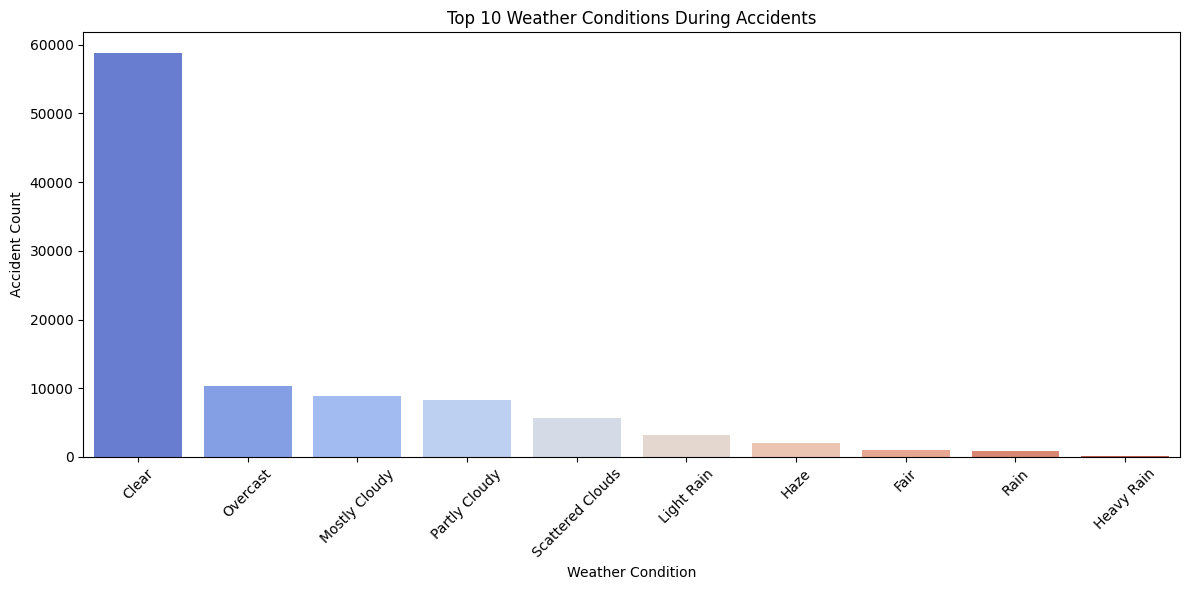

In [15]:
plt.figure(figsize=(12,6))

top_weather = df['Weather_Condition'].value_counts().head(10)

sns.barplot(
    x=top_weather.index,
    y=top_weather.values,
    hue=top_weather.index,
    palette="coolwarm",
    legend=False
)

plt.xticks(rotation=45)
plt.title("Top 10 Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Count")

plt.tight_layout()
plt.show()

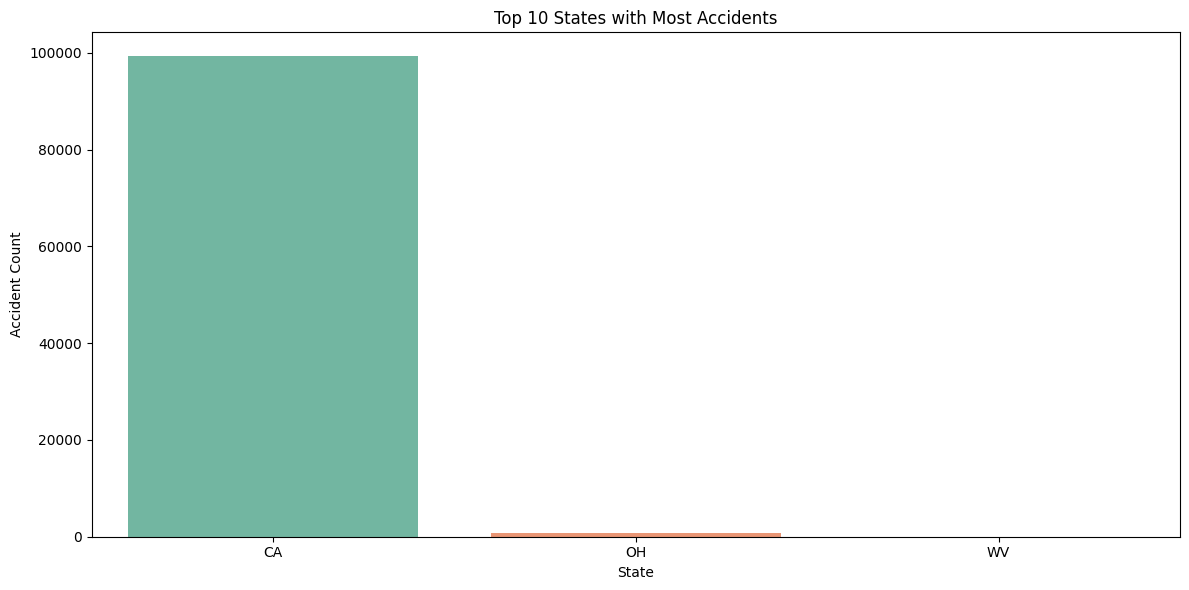

In [16]:
plt.figure(figsize=(12,6))

top_states = df['State'].value_counts().head(10)

sns.barplot(
    x=top_states.index,
    y=top_states.values,
    hue=top_states.index,
    palette="Set2",
    legend=False
)

plt.title("Top 10 States with Most Accidents")
plt.xlabel("State")
plt.ylabel("Accident Count")

plt.tight_layout()
plt.show()

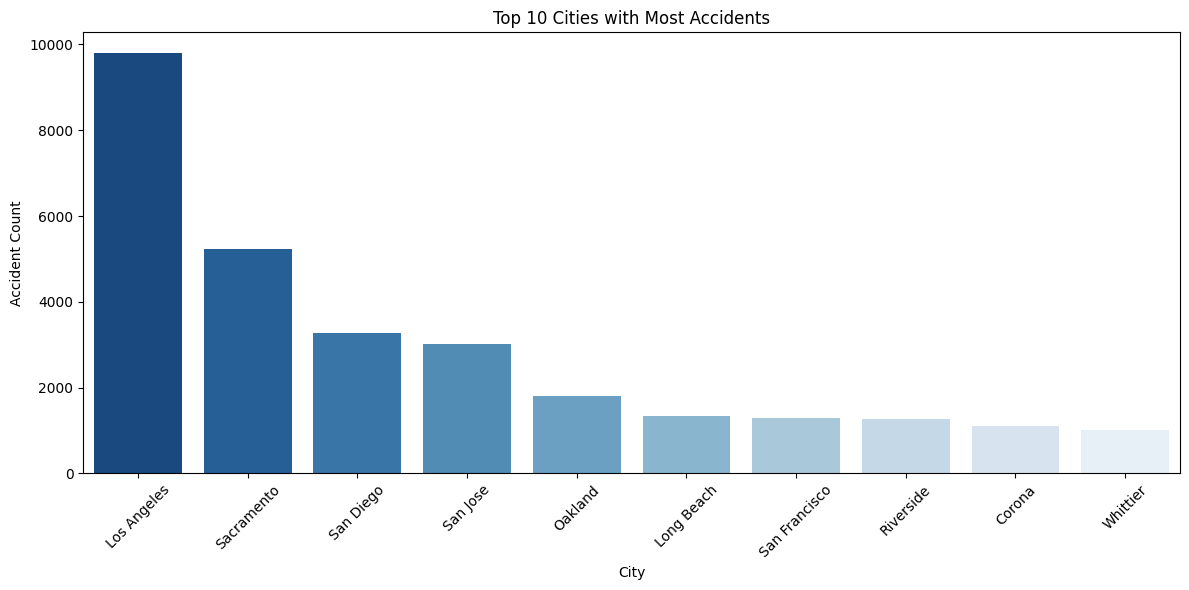

In [17]:
plt.figure(figsize=(12,6))

top_cities = df['City'].value_counts().head(10)

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.index,
    palette="Blues_r",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Top 10 Cities with Most Accidents")
plt.xlabel("City")
plt.ylabel("Accident Count")

plt.tight_layout()
plt.show()

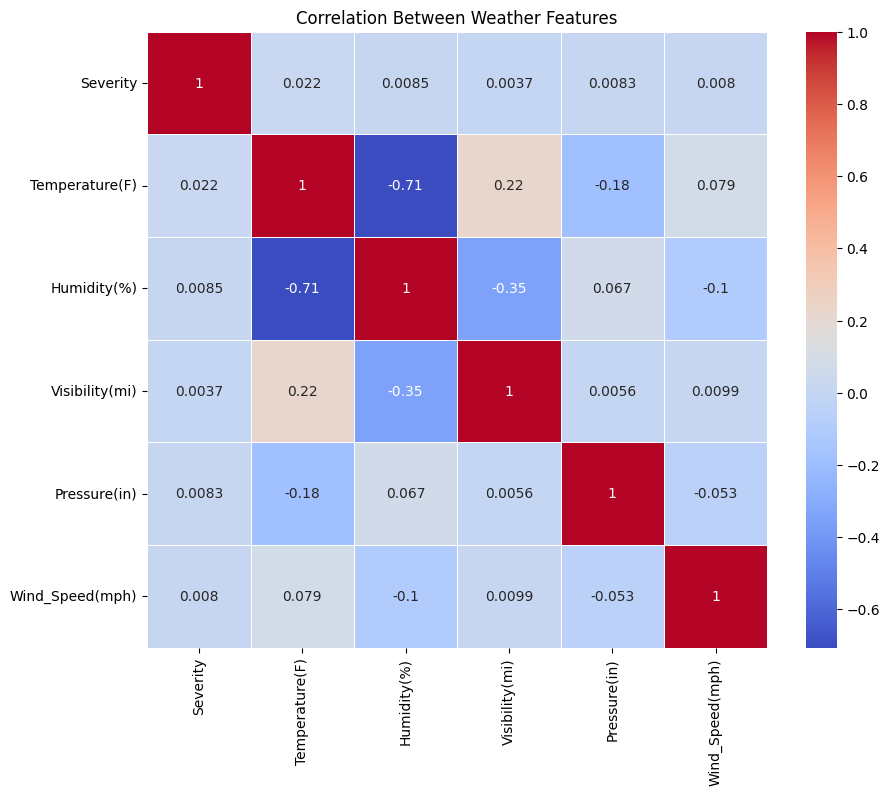

In [18]:
plt.figure(figsize=(10,8))

corr = df[
    [
        'Severity',
        'Temperature(F)',
        'Humidity(%)',
        'Visibility(mi)',
        'Pressure(in)',
        'Wind_Speed(mph)'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Weather Features")

plt.show()

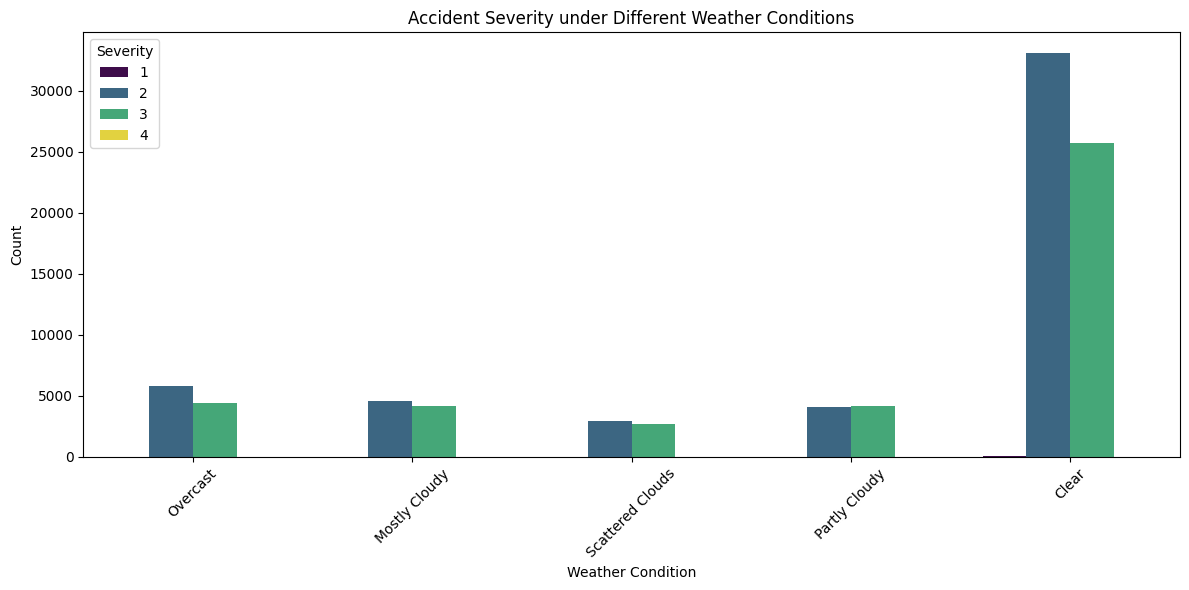

In [19]:
plt.figure(figsize=(12,6))

top_weather = df['Weather_Condition'].value_counts().head(5).index

weather_df = df[df['Weather_Condition'].isin(top_weather)]

sns.countplot(
    data=weather_df,
    x='Weather_Condition',
    hue='Severity',
    palette='viridis'
)

plt.xticks(rotation=45)

plt.title("Accident Severity under Different Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [20]:
print("========== DATASET SUMMARY ==========")

print("Total Accidents :", len(df))
print("Total States :", df['State'].nunique())
print("Total Cities :", df['City'].nunique())

print("\nMost Common Weather Condition:")
print(df['Weather_Condition'].mode()[0])

print("\nAverage Temperature (F):")
print(round(df['Temperature(F)'].mean(),2))

print("\nAverage Visibility (mi):")
print(round(df['Visibility(mi)'].mean(),2))

print("\nAverage Wind Speed (mph):")
print(round(df['Wind_Speed(mph)'].mean(),2))

========== DATASET SUMMARY ==========
Total Accidents : 100000
Total States : 3
Total Cities : 785

Most Common Weather Condition:
Clear

Average Temperature (F):
66.63

Average Visibility (mi):
9.35

Average Wind Speed (mph):
7.77
